In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# benign_data = pd.read_csv(r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\Benign_train.pcap_Flow.csv")
# mqtt_connect = pd.read_csv(r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\MQTT-DDoS-Connect_Flood_train.pcap_Flow.csv")
# mqtt_publish = pd.read_csv(r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\MQTT-DDoS-Publish_Flood_train.pcap_Flow.csv")

In [4]:
def find_best_k(
    csv_path,
    features,
    k_range=(3, 20), 
    sample_size=None,
    random_state=42
):
    df = pd.read_csv(csv_path, usecols=features)
    
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median())  
    

    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=random_state)
        print(f"Using random sample of {len(df)} rows.")
    else:
        print(f"Using all {len(df)} rows.")
    
    #K-Means _Standard Scaler
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df)
    
    scores = []
    for k in range(k_range[0], k_range[1] + 1): 
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(scaled)
        score = silhouette_score(scaled, labels)
        scores.append((k, score))
        print(f"  k={k:2d} → silhouette={score:.4f}")
    
    # Find best k
    best_k, best_score = max(scores, key=lambda x: x[1])
    print(f"\nBest k = {best_k} (silhouette = {best_score:.4f})")
    
    # Plot
    ks, svals = zip(*scores)
    plt.figure(figsize=(10, 6))
    plt.plot(ks, svals, marker='o', linewidth=2, markersize=8)
    plt.title(f"Silhouette Analysis: {Path(csv_path).stem}", fontsize=14)
    plt.xlabel("Number of Clusters (k)", fontsize=12)
    plt.ylabel("Silhouette Score", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return best_k, scores, scaler

Using all 35655 rows.
  k= 3 → silhouette=0.3800
  k= 4 → silhouette=0.3914
  k= 5 → silhouette=0.4019
  k= 6 → silhouette=0.3414
  k= 7 → silhouette=0.3827
  k= 8 → silhouette=0.4196
  k= 9 → silhouette=0.4449
  k=10 → silhouette=0.3998
  k=11 → silhouette=0.4382
  k=12 → silhouette=0.4611
  k=13 → silhouette=0.4882
  k=14 → silhouette=0.5020
  k=15 → silhouette=0.4883
  k=16 → silhouette=0.5023
  k=17 → silhouette=0.5115
  k=18 → silhouette=0.5280
  k=19 → silhouette=0.5238
  k=20 → silhouette=0.5429

Best k = 20 (silhouette = 0.5429)


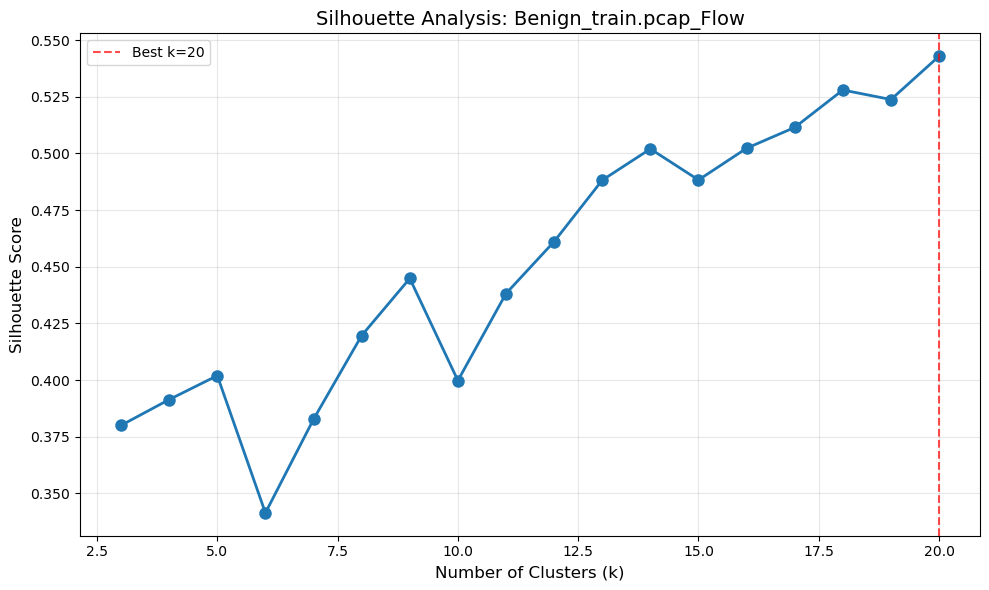

Using random sample of 50000 rows.
  k= 3 → silhouette=0.5147
  k= 4 → silhouette=0.6055
  k= 5 → silhouette=0.6062
  k= 6 → silhouette=0.6212
  k= 7 → silhouette=0.6217
  k= 8 → silhouette=0.6226
  k= 9 → silhouette=0.6389
  k=10 → silhouette=0.6511
  k=11 → silhouette=0.6395
  k=12 → silhouette=0.6514
  k=13 → silhouette=0.6699
  k=14 → silhouette=0.6754
  k=15 → silhouette=0.6718
  k=16 → silhouette=0.6952
  k=17 → silhouette=0.6949
  k=18 → silhouette=0.6933
  k=19 → silhouette=0.6994
  k=20 → silhouette=0.6940

Best k = 19 (silhouette = 0.6994)


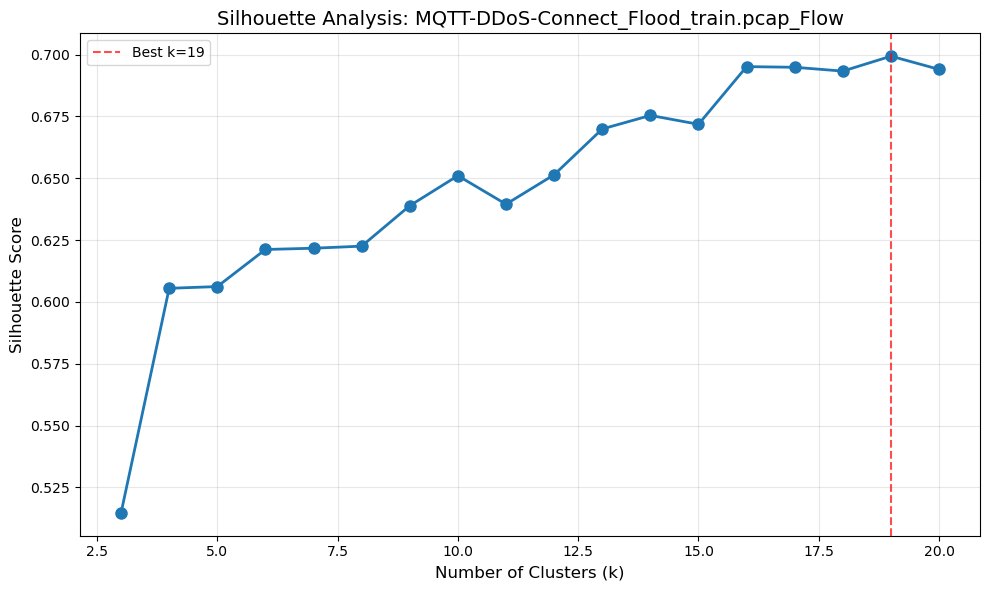

Using random sample of 50000 rows.
  k= 3 → silhouette=0.6920
  k= 4 → silhouette=0.6930
  k= 5 → silhouette=0.7459
  k= 6 → silhouette=0.7473
  k= 7 → silhouette=0.7570
  k= 8 → silhouette=0.7767
  k= 9 → silhouette=0.7862
  k=10 → silhouette=0.7946
  k=11 → silhouette=0.7947
  k=12 → silhouette=0.7950
  k=13 → silhouette=0.8017
  k=14 → silhouette=0.8018
  k=15 → silhouette=0.8018
  k=16 → silhouette=0.8006
  k=17 → silhouette=0.8025
  k=18 → silhouette=0.7915
  k=19 → silhouette=0.7964
  k=20 → silhouette=0.8074

Best k = 20 (silhouette = 0.8074)


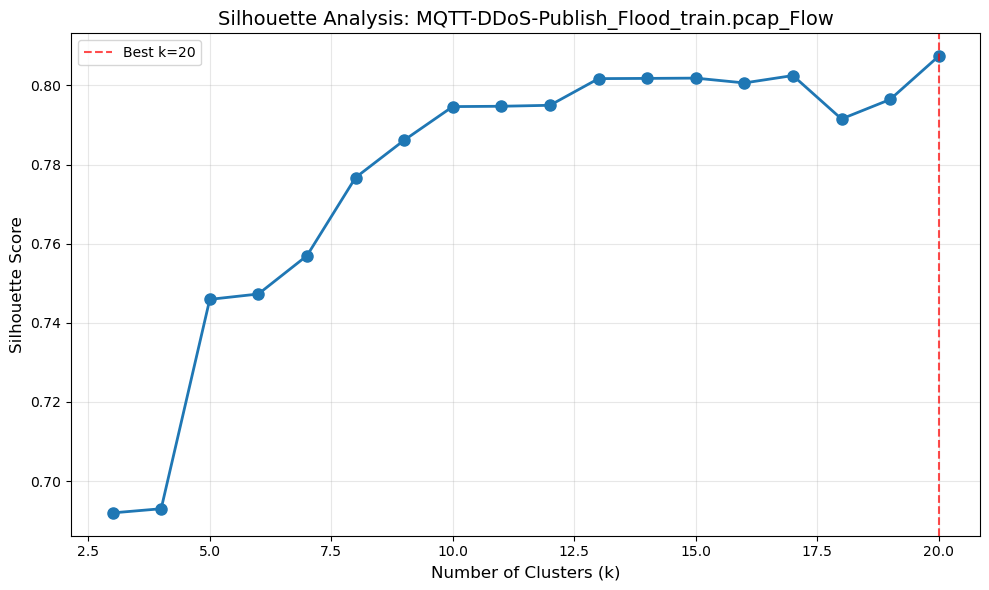

In [5]:
features = [   
    'Flow Duration',
    'Flow Bytes/s', 'Flow Packets/s', 'Down/Up Ratio',   
    'Total Fwd Packet', 'Total Bwd packets',
    'Fwd Header Length', 'Bwd Header Length',
    'FWD Init Win Bytes', 'Bwd Init Win Bytes',    
    'Fwd Seg Size Min', 'Fwd Segment Size Avg',
    'Subflow Fwd Bytes', 'Subflow Bwd Bytes',   
    'Packet Length Min', 'Packet Length Mean',
    'Packet Length Max', 'Packet Length Std',
    'Packet Length Variance', 'Average Packet Size',   
    'Fwd IAT Mean', 'Fwd IAT Total',
    'Bwd IAT Mean', 'Bwd IAT Total',
    'Flow IAT Mean',    
    'SYN Flag Count', 'ACK Flag Count',
    'PSH Flag Count', 'RST Flag Count', 'FIN Flag Count'
]

best_k_benign, scores_benign, scaler_benign = find_best_k(
    r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\Benign_train.pcap_Flow.csv",
    features,
    k_range=(3, 20),
    sample_size=50000
)

best_k_ddos1, scores_ddos1, scaler_ddos1 = find_best_k(
    r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\MQTT-DDoS-Connect_Flood_train.pcap_Flow.csv",
    features,
    k_range=(3, 20),
    sample_size=50000
)

best_k_ddos2, scores_ddos2, scaler_ddos2 = find_best_k(
    r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\MQTT-DDoS-Publish_Flood_train.pcap_Flow.csv",
    features,
    k_range=(3, 20),
    sample_size=50000
)